In [ ]:
#Task 1: Data Understanding (2 Marks)
#1.1 Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
#1.2 Load Dataset
df = pd.read_csv("/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [ ]:
#1.3 Display First 5 Records
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
#1.4 Display Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
#1.5 Summary Statistics
df.describe()
numerical = df.select_dtypes(include=['int64','float64']).columns

print("Numerical Features:")
print(numerical)

Numerical Features:
Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeNumber',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')


In [ ]:
#1.7 Categorical Features
categorical = df.select_dtypes(include=['object']).columns

print("Categorical Features:")
print(categorical)

Categorical Features:
Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')


In [ ]:
#1.8 Target Variable
print(df["Attrition"].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [ ]:
#Task 2: Data Preprocessing
#2.1 Check Missing Values
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [ ]:
#2.2 Remove Unnecessary Columns
df.drop(["EmployeeCount","Over18","StandardHours"],axis=1,inplace=True)

In [ ]:
#2.3 Encode Categorical Columns
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype=="object":
        df[col] = le.fit_transform(df[col])

In [ ]:
#2.4 Train-Test Split (80:20)
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#2.5 Split Features and Target
X = df.drop("Attrition",axis=1)

y = df["Attrition"]

In [ ]:
#Task 3: Model Development
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)
dt_pred = dt.predict(X_test)
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)
rf_pred = rf.predict(X_test)

In [ ]:
#Task 4: Model Evaluation
#4.1 Decision Tree Metrics
print("Decision Tree")

print("Accuracy :",accuracy_score(y_test,dt_pred))

print("Precision :",precision_score(y_test,dt_pred))

print("Recall :",recall_score(y_test,dt_pred))

print("F1 Score :",f1_score(y_test,dt_pred))

Decision Tree
Accuracy : 0.7585034013605442
Precision : 0.11904761904761904
Recall : 0.1282051282051282
F1 Score : 0.12345679012345678


In [ ]:
#4.2 Random Forest Metrics
print("Random Forest")

print("Accuracy :",accuracy_score(y_test,rf_pred))

print("Precision :",precision_score(y_test,rf_pred))

print("Recall :",recall_score(y_test,rf_pred))

print("F1 Score :",f1_score(y_test,rf_pred))

Random Forest
Accuracy : 0.8707482993197279
Precision : 0.5714285714285714
Recall : 0.10256410256410256
F1 Score : 0.17391304347826086


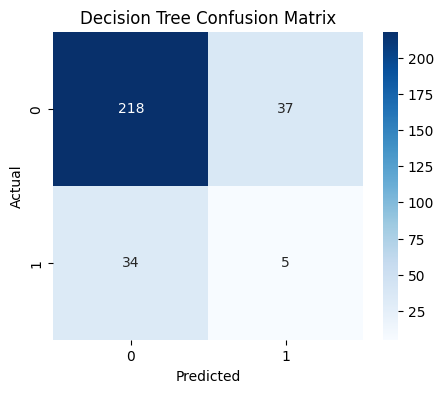

In [ ]:
#4.3 Decision Tree Confusion Matrix
cm = confusion_matrix(y_test,dt_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

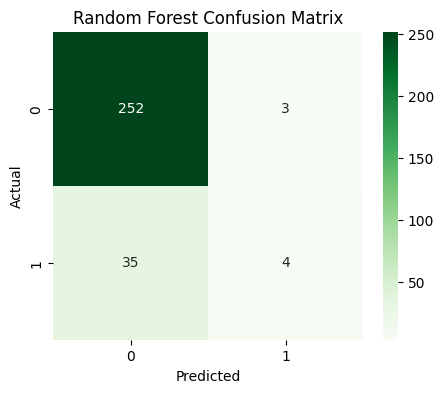

In [ ]:
#4.4 Random Forest Confusion Matrix
cm = confusion_matrix(y_test,rf_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

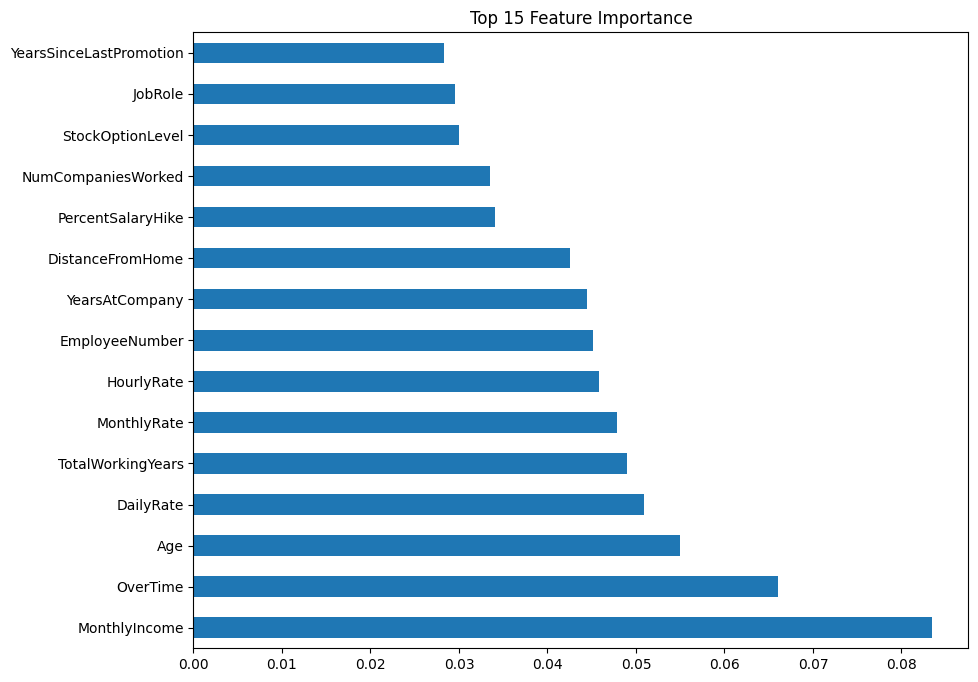

In [ ]:
#4.5 Feature Importance
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,8))

importance.head(15).plot(kind='barh')

plt.title("Top 15 Feature Importance")

plt.show()

In [ ]:
#4.6 Comparison Table
comparison = pd.DataFrame({

    "Model":["Decision Tree","Random Forest"],

    "Accuracy":[
        accuracy_score(y_test,dt_pred),
        accuracy_score(y_test,rf_pred)
    ],

    "Precision":[
        precision_score(y_test,dt_pred),
        precision_score(y_test,rf_pred)
    ],

    "Recall":[
        recall_score(y_test,dt_pred),
        recall_score(y_test,rf_pred)
    ],

    "F1 Score":[
        f1_score(y_test,dt_pred),
        f1_score(y_test,rf_pred)
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.758503,0.119048,0.128205,0.123457
1,Random Forest,0.870748,0.571429,0.102564,0.173913
